# Class 08 — Real EEG signal (MOABB / MNE)

Loading a real motor-imagery dataset (BNCI2014_001) with MOABB, and inspecting it visually before any decoding: raw epoch, class balance, and the power spectral density used to confirm the band-pass filter did its job.

## Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import mne
import matplotlib.pyplot as plt

from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, GroupKFold

from mne.decoding import CSP

from pyriemann.estimation import Covariances
from pyriemann.classification import MDM, TSClassifier

mne.set_log_level("WARNING")
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


/Users/vicky/Documents/motor_imagery_decoding/motor-imagery-decoding/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load subject 1

In [2]:
dataset = BNCI2014_001()
dataset.subject_list = [1]

paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30, tmin=0.5, tmax=3.5)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])


Choosing from all possible events


## Inspect the data

`X` has shape `(n_epochs, n_channels, n_times)`. `y` holds the class label per epoch (`left_hand`, `right_hand`, `feet`, `tongue`). `metadata` is a DataFrame with `subject`, `session`, `run` — used later for group-aware splits.

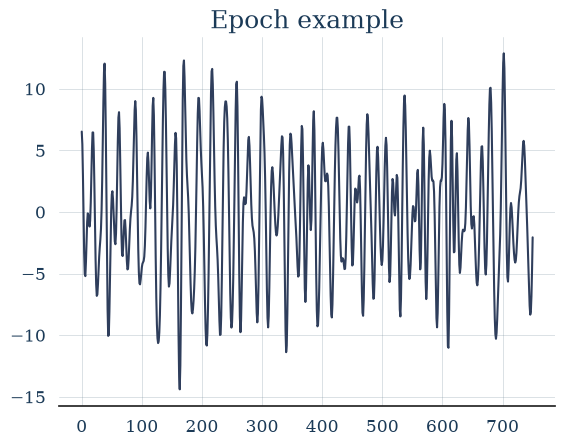

{np.str_('feet'): np.int64(144), np.str_('left_hand'): np.int64(144), np.str_('right_hand'): np.int64(144), np.str_('tongue'): np.int64(144)}


In [3]:
plt.plot(X[0, 0, :])
plt.title("Epoch example")
plt.show()

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))


### Power spectral density

Used to visually verify that the 8-30 Hz band-pass filter worked as intended — the mu/beta rhythm (~10-13 Hz) should show a peak inside the shaded band.

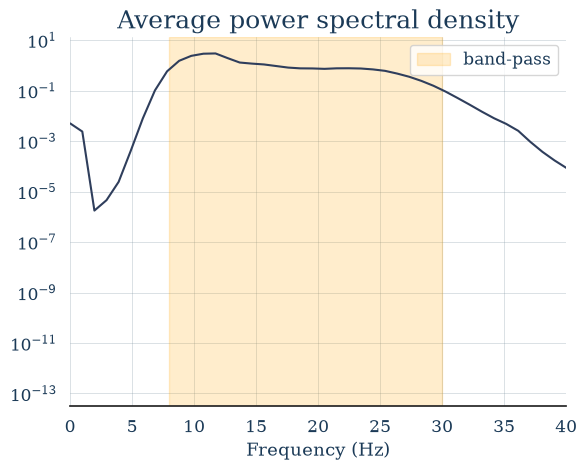

In [4]:
from scipy.signal import welch

sfreq = 250
freqs, psd = welch(X.reshape(-1, X.shape[-1]), fs=sfreq, nperseg=256, axis=-1)

plt.semilogy(freqs, psd.mean(axis=0))
plt.xlim(0, 40)
plt.axvspan(8, 30, color="orange", alpha=0.2, label="band-pass")
plt.title("Average power spectral density")
plt.xlabel("Frequency (Hz)")
plt.legend()
plt.show()
